In [1]:
import openeo

connection = openeo.connect("openeofed.dataspace.copernicus.eu").authenticate_oidc()

Authenticated using refresh token.


## Load Terrascope S2 BIOPAR FAPAR and LAI at 20m resolution

Required:
- Input data: Terrascope S2 BIOPAR LAI and FAPAR at 20m
- Spatial extent: NUTS3 region ‘Tongeren’, gpkg shared in mail thread
- Time window:
    - Season 1: August/2024 – Dec/2025 (the focus is the season Oct/2024 – Oct/2025, but it is good to have some data before and after to test the smoothing/gap filling algorithm)
    - Season 2: August/2025 – now (the focus is the season Oct/2025 – NRT)

In [2]:
import geopandas as gpd

Tongeren_polygon = gpd.read_file("NUTS3_Tongeren.gpkg")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")
# load to 4326
Tongeren_polygon = Tongeren_polygon.to_crs("EPSG:4326")
print(f"type: {type(Tongeren_polygon)} with crs: {Tongeren_polygon.crs}")


type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:3035
type: <class 'geopandas.geodataframe.GeoDataFrame'> with crs: EPSG:4326


In [3]:
# feature collection from geopandas dataframe
import json


aoi = json.loads(Tongeren_polygon.to_json())
aoi

{'type': 'FeatureCollection',
 'features': [{'id': '0',
   'type': 'Feature',
   'properties': {'NUTS_ID': 'BE223',
    'LEVL_CODE': 3,
    'CNTR_CODE': 'BE',
    'NAME_LATN': 'Arr. Tongeren',
    'NUTS_NAME': 'Arr. Tongeren',
    'MOUNT_TYPE': None,
    'URBN_TYPE': 2,
    'COAST_TYPE': None,
    'NAME_ENGL': 'Belgium',
    'NAME_FREN': 'Belgique',
    'ISO3_CODE': 'BEL',
    'SVRG_UN': 'UN Member State',
    'CAPT': 'Brussels',
    'EU_STAT': 'T',
    'EFTA_STAT': 'F',
    'CC_STAT': 'F',
    'NAME_GERM': 'Belgien'},
   'geometry': {'type': 'MultiPolygon',
    'coordinates': [[[[5.744863551499609, 51.010992429287434],
       [5.751944530764668, 51.00683604793922],
       [5.7660741051662034, 51.00859429249384],
       [5.76507201766657, 50.99722077605473],
       [5.748910981777741, 50.98248295606365],
       [5.745662737402827, 50.981270948075796],
       [5.7380072331828895, 50.97841447451071],
       [5.7210962388270765, 50.96164985464712],
       [5.722445042041708, 50.9579098742

In [4]:
# Time window:
# - Season 1: August/2024 – Dec/2025 (the focus is the season Oct/2024 – Oct/2025, but it is good to have some data before and after to test the smoothing/gap filling algorithm)
# - Season 2: August/2025 – now (the focus is the season Oct/2025 – NRT)

In [5]:
s2_fapar = connection.load_stac(
    url = "https://stac.terrascope.be/collections/terrascope-s2-fapar-v2",
    spatial_extent = aoi,
    temporal_extent = ["2025-01-01", "2025-01-31"],
    bands = ["FAPAR"]
)
s2_lai = connection.load_stac(
    url = "https://stac.terrascope.be/collections/terrascope-s2-lai-v2",
    spatial_extent = aoi,
    temporal_extent = ["2025-01-01", "2025-01-31"],
    bands = ["LAI"]
)

In [6]:
# s2_fapar.execute_batch(title = "test s2_fapar for Tongeren")

In [7]:
# s2_lai.execute_batch(title = "test s2_lai for Tongeren")

## Filter FAPAR and LAI based on a parcel delineation map

More data on the gpkg in ticket and mail.

In [8]:
# load field from parcel delination
fields = gpd.read_file("AGRIPRC2026_Tongeren_selection.gpkg")
fields = fields.to_crs("EPSG:4326")
subset_fields = fields[:10]  # select first 10 fields for testing

In [9]:
fapar_timeseries = s2_fapar.aggregate_spatial(json.loads(subset_fields.to_json()), reducer="median")
# fapar_timeseries.execute_batch(title="test fapar_timeseries for Tongeren", outputfile="fapar_timeseries.csv")

In [10]:
delination_map = s2_fapar.filter_spatial(json.loads(subset_fields.to_json()))

In [11]:
# import os
# OUTPUT_PATCH_DIR = "delination_map_patches"
# os.makedirs(OUTPUT_PATCH_DIR, exist_ok=True)

# # Export one GeoTIFF per training polygon.
# job = delination_map.create_job(
#     out_format="GTiff",
#     title="delinated fapar",
#     sample_by_feature=True,
#     feature_id_property="AGPAKEY",
# )
# job.start_and_wait()
# job.get_results().download_files(OUTPUT_PATCH_DIR)

## Run a Whittaker smoother for 2 scenarios:

- Pixel-based
- On Average FAPAR / LAI per parcel

The whittaker smoother requires a lambda parameter. Will need to follow up if it is whittaker service or a local implementation.

In [12]:
# apply Whittaker smoothing UDF along the temporal dimension
smoothed = s2_fapar.apply_dimension(
    process=openeo.UDF.from_file("udf_whittaker.py"),
    dimension="t",
    context={"lmbda": 15, "d": 2},
)

In [13]:
fapar_timeseries_smoothed = smoothed.aggregate_spatial(json.loads(subset_fields.to_json()), reducer="median")
fapar_timeseries_smoothed.execute_batch(title="test fapar_timeseries smoothed for Tongeren", outputfile="fapar_timeseries_smoothed.csv")

Preflight process graph validation raised: [UpstreamValidationFailure] Validation failed on backend cdse: OpenEoApiPlainError('[403] {"status":"error","data":{"message":"This request was rejected due to a violation. Please consult with your administrator, and provide this reference ID:  9047016161713299362"}}')


0:00:00 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': send 'start'
0:00:04 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': created (progress 0%)
0:00:09 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': queued (progress 0%)
0:00:16 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': queued (progress 0%)
0:00:25 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': queued (progress 0%)
0:00:35 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': queued (progress 0%)
0:00:47 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': running (progress N/A)
0:01:03 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': running (progress N/A)
0:01:22 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': running (progress N/A)
0:01:47 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': running (progress N/A)
0:02:17 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': running (progress N/A)
0:02:54 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': running (progress N/A)
0:03:41 Job 'cdse-j-2608281206224e70af619ee36cedb7ff': running (progress N/A)
0:04:

<BatchJob job_id='cdse-j-2608281206224e70af619ee36cedb7ff'>

In [28]:
import matplotlib.pyplot as plt
import pandas as pd

fapar_timeseries = pd.read_csv("fapar_timeseries.csv", index_col=0, parse_dates=True)
fapar_timeseries_smoothed = pd.read_csv("fapar_timeseries_smoothed.csv", index_col=0, parse_dates=True)


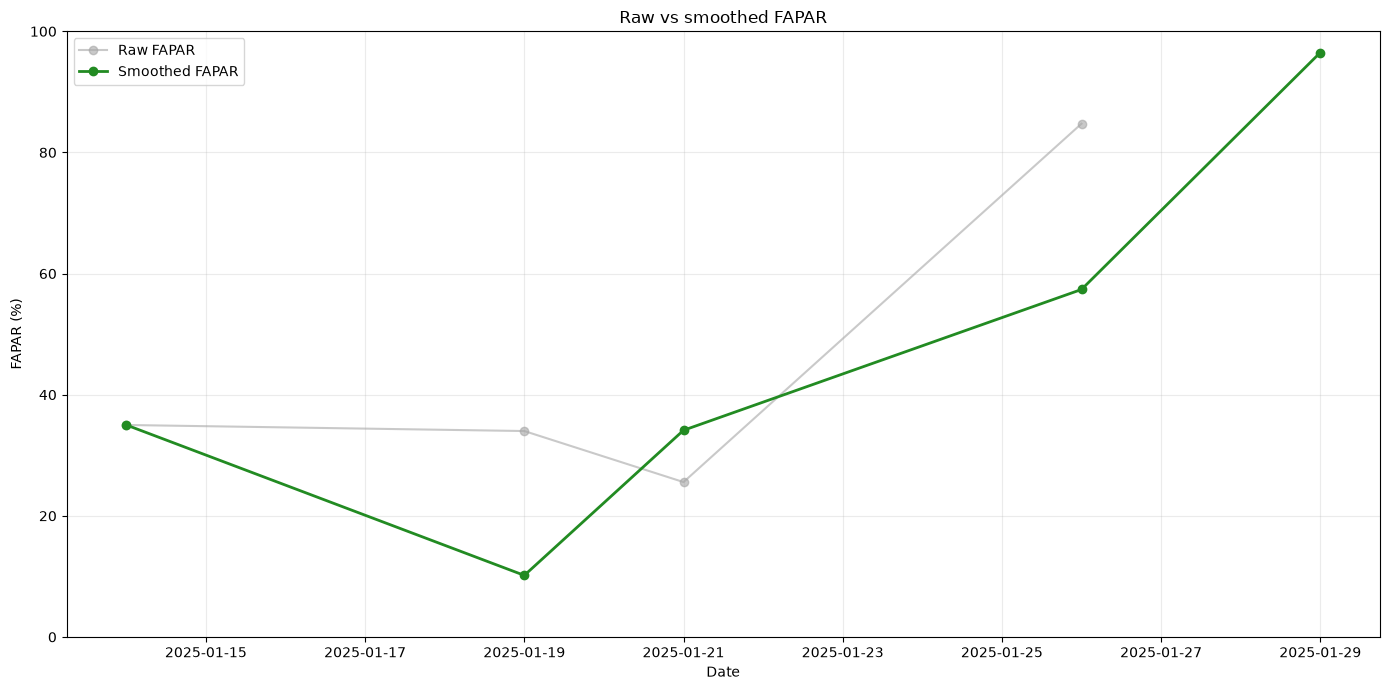

In [29]:
raw_fapar = (
    pd.to_numeric(fapar_timeseries["FAPAR"])
    .groupby(level=0)
    .mean()
    .sort_index()
    .rename("Raw FAPAR")
)

smoothed_fapar = (
    pd.to_numeric(fapar_timeseries_smoothed["FAPAR"])
    .groupby(level=0)
    .mean()
    .sort_index()
    .rename("Smoothed FAPAR")
)

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(
    raw_fapar.index,
    raw_fapar,
    color="0.65",
    marker="o",
    linewidth=1.5,
    alpha=0.6,
    label="Raw FAPAR",
)

ax.plot(
    smoothed_fapar.index,
    smoothed_fapar,
    color="forestgreen",
    marker="o",
    linewidth=2,
    label="Smoothed FAPAR",
)

ax.set_title("Raw vs smoothed FAPAR")
ax.set_xlabel("Date")
ax.set_ylabel("FAPAR (%)")
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.25)
ax.legend()

fig.tight_layout()
plt.show()

In [28]:
# smoothed.execute_batch(title = "test whittaker for Tongeren")

In [ ]:
from fusets.openeo import load_whittakker_udf

pixel_based_whittaker = s2_fapar.apply_dimension(
    process=lambda x: x.run_udf(
        udf=(
            Path(__file__).parent.parent.parent / "utils" / "set_dependency_path.py"
        ).read_text()
        + "\n"
        + load_whittakker_udf(),
        runtime="Python",
        version="3.8",
        context={"smoothing_lambda": 10000},
    ),
    dimension="t",
)

NameError: name 'Path' is not defined